In [2]:
import numpy as np
from astropy.table import Table
from astropy.io import fits
import catalogue_analysis as ca
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [6]:
#Define which catalogues to inspect
reg="N"
ABSMAGLIM=-8
date='25thSep'

obs_seed= 000
sig_lgv = 0.2
min_Vpeak=70.0       #Discard all halos with Vpeak<min_Vpeak. This limits the redshift below which the mock is complete  
N_neigh_vpeak = 1000 #with 1000 the logVpeak scatter among neighbours is < 10^-6 and so will introduce no more than 10^-5 scatter in the magnitude relation

ran_inpcat=rf'./sdata/Mocks/rancat{date}_fordata_{reg}.fits' 
rancat=rf'./sdata/Mocks/rancat{date}_formock_{reg}.fits'

mockcat=rf'./sdata/Mocks/mock_{reg}_seed{obs_seed:03d}_sig_lgv{sig_lgv:.2f}.fits'#file to store resulting mock catalogue

datcat=rf'./sdata/Mocks/BGS_BRIGHT_{date}.fits'


In [7]:
# Read the mock catalogue
mock=Table.read(mockcat)
mock.info('stats')

<Table length=3716638>
    name        mean        std         min         max    
----------- ----------- ----------- ----------- -----------
         ID 8.51672e+14 2.06153e+14 2.11662e+13 2.17071e+15
        pid 2.55212e+13 4.73487e+13          -1 2.70652e+14
   Mvir_all 3.90038e+12 1.84409e+13 1.14457e+09  2.3537e+15
      Vpeak     346.291     213.237     25.8437      7103.7
          x    -224.284     186.956    -1105.66      251.98
          y    -49.5098     284.643    -1104.98     1037.95
          z     453.426     219.747       16.63     1289.21
Mpeak_Scale    0.730257    0.139717    0.104035     0.84235
       dist      593.04     266.303     29.9275      1316.1
        DEC     51.5078     12.2828      32.375     79.2779
         RA      192.48     52.8912      90.336     298.266
       conc       14.35     25.2223     1.00045     14773.3
          Z     0.21106   0.0998968   0.0100063    0.499999
       Zobs    0.211147   0.0997399  0.00988379    0.509696
  FracZpeak    0.

In [8]:
# Read the random catalogue
ran=Table.read(rancat)
#print('data type of ran[TARGETID]:',ran['TARGETID'].dtype)

ran.info('stats')

<Table length=28756157>
    name         mean        std         min         max    
------------ ----------- ----------- ----------- -----------
          RA     191.617     52.9432       90.33     298.306
         DEC     51.4079     12.2711      32.375     79.2807
         reg          --          --          --          --
  ABSMAG_RP1    -20.1909     1.23423    -25.0229    -12.7126
    ABSMAG_R    -20.1838     1.23453    -25.2948    -12.7267
  ABSMAG_GP1    -19.4226     1.13425    -24.9223    -11.7497
REST_GMR_0P1    0.753883      0.2059   -0.196756     1.39771
           v 1.31552e+08 1.52401e+08     10398.6 8.85971e+08
           Z     0.21096   0.0998051   0.0100003         0.5
        rmag     18.6615    0.831618     10.1572       19.54
        gmag     19.6858    0.963127     10.9555     21.5035
        zmin        0.01 4.51028e-16        0.01        0.01
        zmax    0.285669    0.109744   0.0101102         0.5
    TARGETID 3.96332e+16 1.75477e+11 3.96329e+16 3.96335e+16


In [9]:
# Read the initial random catalogue that should match the data
ran_inp=Table.read(ran_inpcat)
ran_inp.info('stats')

<Table length=28756157>
    name         mean        std         min         max    
------------ ----------- ----------- ----------- -----------
          RA     192.496     51.9189      90.377     298.245
         DEC      51.078     12.0878      32.375     79.2697
         reg          --          --          --          --
  ABSMAG_RP1    -20.1909     1.23423    -25.0229    -12.7126
    ABSMAG_R    -20.1838     1.23453    -25.2948    -12.7267
  ABSMAG_GP1    -19.4226     1.13425    -24.9223    -11.7497
REST_GMR_0P1    0.753883      0.2059   -0.196756     1.39771
           v 1.31552e+08 1.52401e+08     10398.6 8.85971e+08
           Z     0.21096   0.0998051   0.0100003         0.5
        rmag     18.6615    0.831618     10.1572       19.54
        gmag     19.6858    0.963127     10.9555     21.5035
        zmin        0.01 4.51028e-16        0.01        0.01
        zmax    0.285669    0.109744   0.0101102         0.5
    TARGETID 3.96332e+16 1.75477e+11 3.96329e+16 3.96335e+16


In [10]:
# Read the data catalogue
dat=Table.read(datcat)
mask=(dat['reg']==reg)
dat=dat[mask].copy()
dat.info('stats')

<Table length=2423144>
       name            mean         std         min          max    
------------------ ------------ ----------- ------------ -----------
          TARGETID  3.96332e+16 1.75782e+11  3.96329e+16 3.96335e+16
            TILEID      23098.5     1884.05        20001       27801
                 Z      0.21258    0.100382    0.0100004         0.5
             NTILE      2.48128    0.949605            1           5
                RA      193.052     52.0001       90.368     298.001
               DEC      50.9519     12.0626       32.375     79.2584
               reg           --          --           --          --
  FRAC_TLOBS_TILES     0.984462    0.027089     0.333333           1
      WEIGHT_ZFAIL      1.00114  0.00466275            1     1.15863
        BITWEIGHTS -4.18343e+14 3.00041e+18 -9.22337e+18 9.22337e+18
          PROB_OBS      0.85787    0.207904            0           1
            WEIGHT      1.32451    0.750346            1     129.036
       WEIG

In [11]:
#Apply absolute magnitude cut to all catalogues
mask = (mock['ABSMAG_RP1']<ABSMAGLIM)
mock=mock[mask]
mask = (dat['ABSMAG_RP1']<ABSMAGLIM)
dat=dat[mask]
mask = (ran['ABSMAG_RP1']<ABSMAGLIM)
ran=ran[mask]
mask = (ran_inp['ABSMAG_RP1']<ABSMAGLIM)
ran_inp=ran_inp[mask]

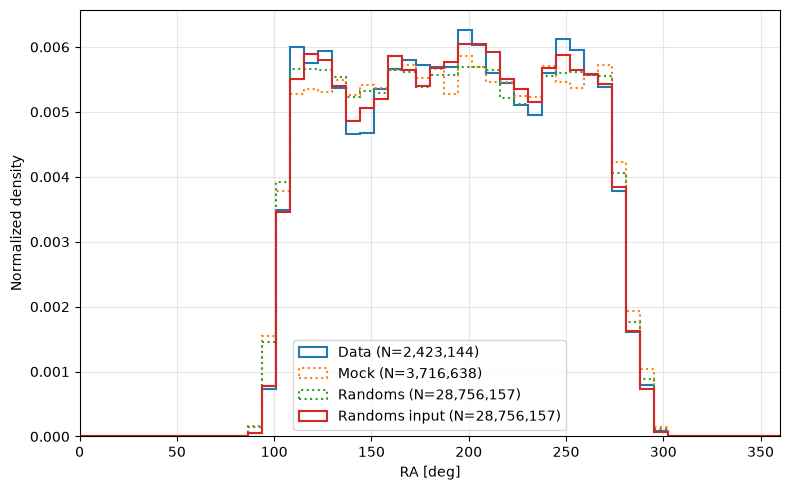

In [12]:
#Compare RA distributions

fig, ax = plt.subplots(figsize=(8,5))

bins = np.linspace(00, 360, 51)   # 30 bins

ax.hist(dat['RA'],
        bins=bins,
        density=True,
        histtype='step',
        linewidth=1.5,
        weights=dat['WEIGHT'],
        label=f'Data (N={len(dat):,})')


ax.hist(mock['RA'],
        bins=bins,
        density=True,
        histtype='step',
        linestyle='dotted',
        linewidth=1.5,
        label=f'Mock (N={len(mock):,})')

ax.hist(ran['RA'],
        bins=bins,
        density=True,
        histtype='step',
        linestyle='dotted',
        linewidth=1.5,
        label=f'Randoms (N={len(ran):,})')





ax.hist(ran_inp['RA'],
        bins=bins,
        density=True,
        histtype='step',
        linewidth=1.5,
       label=f'Randoms input (N={len(ran_inp):,})')



ax.set_xlabel('RA [deg]')
ax.set_ylabel('Normalized density')
ax.set_xlim(0, 360)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


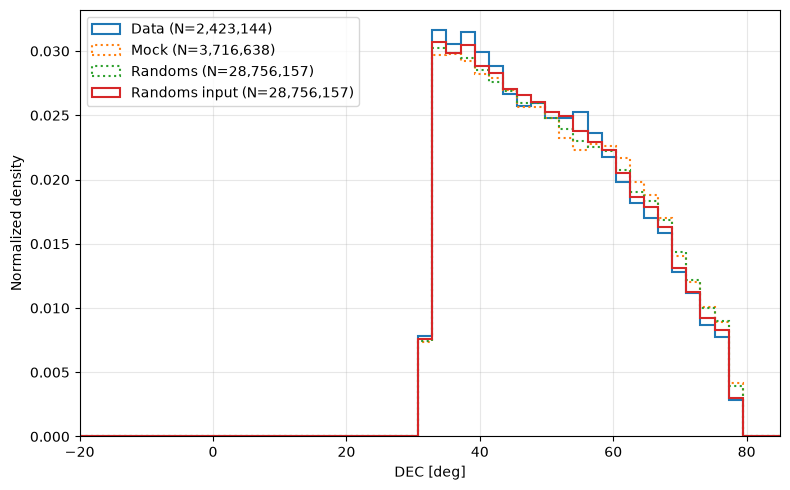

In [13]:
#Compare DEC distributions
fig, ax = plt.subplots(figsize=(8,5))

bins = np.linspace(-20, 90, 53)   # 30 bins

ax.hist(dat['DEC'],
        bins=bins,
        density=True,
        histtype='step',
        linewidth=1.5,
        weights=dat['WEIGHT'],
        label=f'Data (N={len(dat):,})')


ax.hist(mock['DEC'],
        bins=bins,
        density=True,
        histtype='step',
        linewidth=1.5,
        linestyle='dotted',
        label=f'Mock (N={len(mock):,})')


ax.hist(ran['DEC'],
        bins=bins,
        density=True,
        histtype='step',
        linewidth=1.5,
        linestyle='dotted',
        label=f'Randoms (N={len(ran):,})')


ax.hist(ran_inp['DEC'],
        bins=bins,
        density=True,
        histtype='step',
        linewidth=1.5,
        label=f'Randoms input (N={len(ran):,})')


ax.set_xlabel('DEC [deg]')
ax.set_ylabel('Normalized density')
ax.set_xlim(-20, 85)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


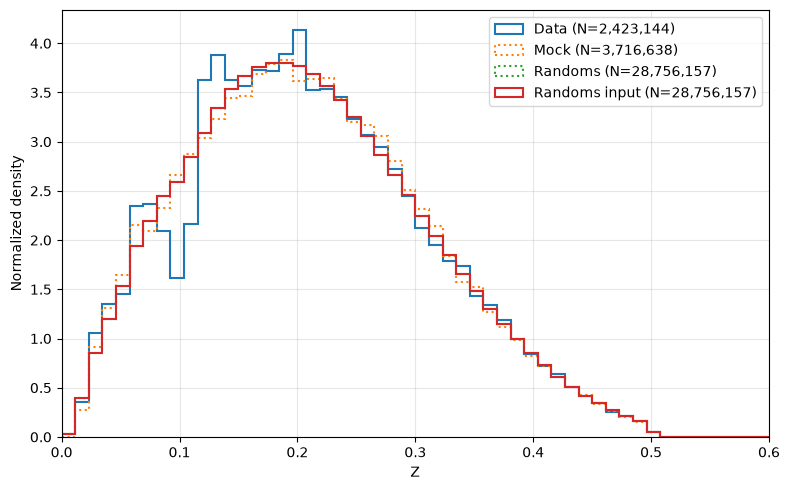

In [14]:
#Compare Z distributions
fig, ax = plt.subplots(figsize=(8,5))

bins = np.linspace(0, 0.6, 53)   # 30 bins

ax.hist(dat['Z'],
        bins=bins,
        density=True,
        histtype='step',
        linewidth=1.5,
        weights=dat['WEIGHT'],
        label=f'Data (N={len(dat):,})')


ax.hist(mock['Zobs'],
        bins=bins,
        density=True,
        histtype='step',
        linewidth=1.5,
        linestyle='dotted',
        label=f'Mock (N={len(mock):,})')


ax.hist(ran['Z'],
        bins=bins,
        density=True,
        histtype='step',
        linewidth=1.5,
        linestyle='dotted',
        label=f'Randoms (N={len(ran):,})')


ax.hist(ran_inp['Z'],
        bins=bins,
        density=True,
        histtype='step',
        linewidth=1.5,
        label=f'Randoms input (N={len(ran):,})')


ax.set_xlabel('Z')
ax.set_ylabel('Normalized density')
ax.set_xlim(0, 0.6)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [15]:
#Checking definition of NMULT factor.
NMULT_formock=ran.meta["NMULT"]
NMULT_fordata=ran_inp.meta["NMULT"]
Sel=ca.selection(reg)
fsky_fordata=Sel['area']
fsky_formock=ran.meta["FSKY"]
print(rf"fsky  data={fsky_fordata:.3f}  mock={fsky_formock:.3f}")      
print('data weight sum:',dat['WEIGHT'].sum())
print('number of randoms:',len(ran['RA']))
print('ratio randoms to weighted data',len(ran_inp['RA'])/dat['WEIGHT'].sum(),' NMULT=',NMULT_fordata,' Normalization off by factor:',(len(ran_inp['RA'])/dat['WEIGHT'].sum())/NMULT_fordata)

fsky  data=0.093  mock=0.109
data weight sum: 3209468.152202842
number of randoms: 28756157
ratio randoms to weighted data 8.959788861049455  NMULT= 8.959788861049455  Normalization off by factor: 1.0


3716638
28756157
7.637669030697811
3765043.6127071497
The randoms match the data when scaled by NMULT but we find we need to scale the mocks by an additional: 1.0130240321245032 This ought not to be the case!
fsky  data=0.093  mock=0.109


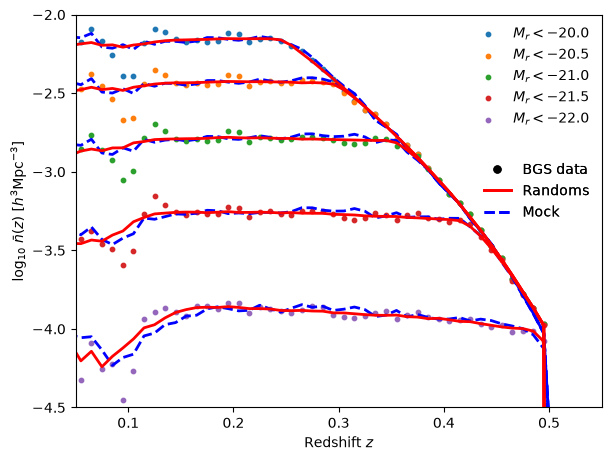

If shown (show_both_randoms= True), the dashed cyan line it the Randoms for data and should be identical to the red line


In [16]:
show_both_randoms = False  # Select whether to show the N(z) of the "for data" randoms as well as the the "for mocks" randoms. They ought to be the same

print(len(mock))
print(len(ran))
print(NMULT_formock)
print((len(ran)/NMULT_formock))

scale=(len(ran)/NMULT_formock)/len(mock) 
print('The randoms match the data when scaled by NMULT but we find we need to scale the mocks by an additional:',scale, 'This ought not to be the case!' )

#number density versus Redshift
# -----------------------------------------
# Plot
# -----------------------------------------
fig, ax = plt.subplots(
    figsize=(6,4.5),
    constrained_layout=True
)

Sel=ca.selection(reg)
eps=1.0e-25
f_sky=Sel['area']
print(rf"fsky  data={f_sky:.3f}  mock={ran.meta["FSKY"]:.3f}")

magcuts = [-20.0, -20.5, -21.0, -21.5, -22.0]
colors = ['C0','C1','C2','C3','C4']

# redshift bins
zbins = np.linspace(0.0, 0.6, 61)
zcen = 0.5 * (zbins[:-1] + zbins[1:])

# -----------------------------------------
# Comoving volumes of redshift shells
# -----------------------------------------

dc = ca.cosmo.comoving_distance(zbins).value   # Mpc/h

vol_dat = (
    (4.0*np.pi*f_sky/3.0)
    * (dc[1:]**3 - dc[:-1]**3)
)

vol_mock = (
    (4.0*np.pi*ran.meta['FSKY']/3.0)
    * (dc[1:]**3 - dc[:-1]**3)
)


for Mcut, c in zip(magcuts, colors): 

    # -----------------------------------------
    # Full weighted data histogram
    # -----------------------------------------

    weights = np.asarray(dat['WEIGHT'])
    mask = dat['ABSMAG_RP1'] < Mcut
    #print(weights[mask].sum()
    
    h_dat, edges = np.histogram(
        dat['Z'][mask],
        bins=zbins,
        weights=weights[mask]
    )

    n_dat = h_dat / vol_dat
    log_dat  = np.log10(n_dat+eps)
    label = rf'$M_r < {Mcut:.1f}$'
    ax.scatter(
        zcen,
        log_dat,
        color=c,
        s=10,
        marker='o',
        label=label
    )




for Mcut in magcuts: 
    # -----------------------------------------
    # Mock catalogue
    # -----------------------------------------
    mask = mock['ABSMAG_RP1'] < Mcut
    h_mock, _ = np.histogram(
        mock['Zobs'][mask],
        bins=zbins
    )

    n_mock = h_mock / vol_mock
    log_mock = np.log10(n_mock*scale+eps)


    ax.plot(
        zcen,
        log_mock,
        color='blue',
        lw=2,
        ls='--',
        #label='Mock'
    )

for Mcut in magcuts: 
    # -----------------------------------------
    # Random catalogue
    # -----------------------------------------
    mask = ran['ABSMAG_RP1'] < Mcut
    h_ran, _ = np.histogram(
        ran['Z'][mask],
        bins=zbins
    )

    n_ran = h_ran / (vol_mock*NMULT_formock)
    log_ran = np.log10(n_ran+eps)


    ax.plot(
        zcen,
        log_ran,
        color='red',
        lw=2,
        ls='solid',
        #label='Random'
    )

if show_both_randoms:
    for Mcut in magcuts: 
        # -----------------------------------------
        # Random catalogue for data
        # -----------------------------------------
        mask = ran['ABSMAG_RP1'] < Mcut
        h_ran, _ = np.histogram(
            ran['Z'][mask],
            bins=zbins
        )

        n_ran = h_ran / (vol_dat*NMULT_fordata)
        log_ran = np.log10(n_ran+eps)


        ax.plot(
            zcen,
            log_ran,
            color='cyan',
            lw=2,
            ls='dashed',
            #label='Randoms for data'
        )


ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'$\log_{10}\, \bar{n}(z)\  [h^3 {\rm Mpc}^{-3}]$')
ax.set_ylim([-4.5,-2])
ax.set_xlim([0.05,0.55])
ax.legend(frameon=False)

from matplotlib.lines import Line2D

style_handles = [
    Line2D([0],[0], marker='o', color='none',
           markerfacecolor='black',
           markersize=5,
           label='BGS data'),
    Line2D([0],[0], color='red', lw=2,
           label='Randoms'),
    Line2D([0],[0], color='blue', lw=2, ls='--',
           label='Mock')
]
# First legend (magnitude cuts)
leg1 = ax.legend(
    frameon=False,
    loc='upper right'
)

leg2 = ax.legend(
    handles=style_handles,
    frameon=False,
    bbox_to_anchor=(1.0, 0.55),
    loc='center right'
)
ax.add_artist(leg1)


ax.add_artist(leg2)

plt.savefig("nz.pdf", bbox_inches="tight")
plt.show()
print('If shown (show_both_randoms= True), the dashed cyan line it the Randoms for data and should be identical to the red line')

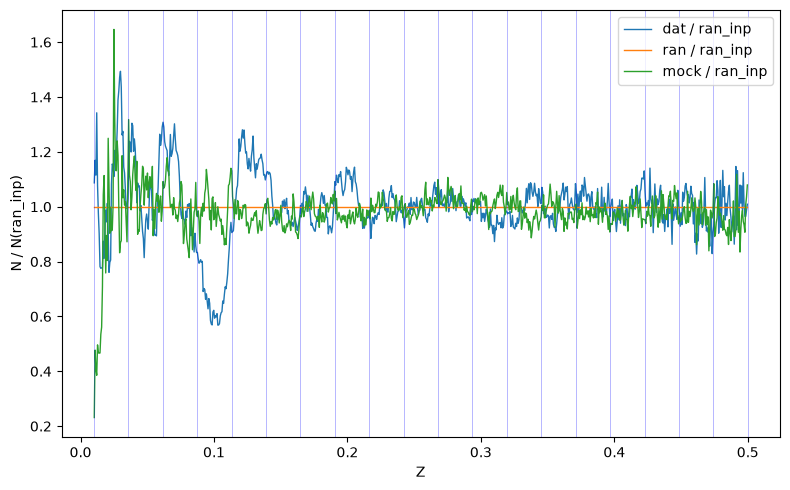

In [17]:
z_bins = np.linspace(0.01, 0.5, 800)


# Histograms
h_dat, edges = np.histogram(dat['Z'], bins=z_bins, weights=dat['WEIGHT'])
h_dat=h_dat/fsky_fordata
h_ran, _     = np.histogram(ran['Z'], bins=z_bins)
h_ran=h_ran/(fsky_formock*NMULT_formock)
h_mock, _    = np.histogram(mock['Z'], bins=z_bins)
h_mock=h_mock/fsky_formock
h_raninp, _  = np.histogram(ran_inp['Z'], bins=z_bins)
h_raninp=h_raninp/(fsky_fordata*NMULT_fordata)
# Bin centres
z = 0.5 * (edges[:-1] + edges[1:])



# Safe division
ratio_dat  = np.divide(h_dat,  h_raninp,
                       out=np.full_like(h_dat, np.nan, dtype=float),
                       where=h_raninp > 0)

ratio_ran  = np.divide(h_ran,  h_raninp,
                       out=np.full_like(h_ran, np.nan, dtype=float),
                       where=h_raninp > 0)

ratio_mock = np.divide(h_mock, h_raninp,
                       out=np.full_like(h_mock, np.nan, dtype=float),
                       where=h_raninp > 0)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(z, ratio_dat,  label='dat / ran_inp',  lw=1)
ax.plot(z, ratio_ran,  label='ran / ran_inp',  lw=1)
ax.plot(z, ratio_mock, label='mock / ran_inp', lw=1)

zmaxes = np.linspace(0.01, 0.5, 20)

for zmax in zmaxes:
    ax.axvline(zmax, color='blue', lw=0.5, alpha=0.4)
ax.set_xlabel('Z')
ax.set_ylabel('N / N(ran_inp)')
ax.legend()
#ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

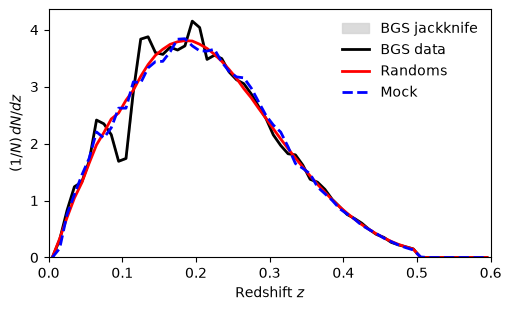

In [18]:
#Redshift distribution plot
# -----------------------------------------
# Plot
# -----------------------------------------
fig, ax = plt.subplots(
    figsize=(5,3),
    constrained_layout=True
)


# redshift bins
zbins = np.linspace(0.0, 0.6, 61)
zcen = 0.5 * (zbins[:-1] + zbins[1:])

# -----------------------------------------
# Full weighted data histogram
# -----------------------------------------

weights = np.asarray(dat['WEIGHT'])

h_dat, edges = np.histogram(
    dat['Z'],
    bins=zbins,
    weights=weights
)

dz = edges[1] - edges[0]

h_dat = h_dat / (h_dat.sum() * dz)

# -----------------------------------------
# Jackknife estimates
# -----------------------------------------

if (reg=='N'): 
    njack = 9
    offset=20
elif (reg=='S'):
    njack=20
    offset =0

jk_hists = []

for ijack in range(njack):

    mask = (dat['ijack']-offset != ijack)

    h, _ = np.histogram(
        dat['Z'][mask],
        bins=zbins,
        weights=weights[mask]
    )

    h = h / (h.sum() * dz)

    jk_hists.append(h)

jk_hists = np.asarray(jk_hists)

jk_mean = np.mean(jk_hists, axis=0)

jk_err = (
    np.std(jk_hists, axis=0)
    * np.sqrt(njack - 1)
)

# -----------------------------------------
# Random catalogue
# -----------------------------------------
h_ran, _ = np.histogram(
    ran['Z'],
    bins=zbins
)

h_ran = h_ran / (h_ran.sum() * dz)

# -----------------------------------------
# Mock catalogue
# -----------------------------------------
h_mock, _ = np.histogram(
    mock['Zobs'],
    bins=zbins
)

h_mock = h_mock / (h_mock.sum() * dz)


ax.fill_between(
    zcen,
    h_dat - jk_err,
    h_dat + jk_err,
    color='lightgrey',
    alpha=0.8,
    label='BGS jackknife'
)

ax.plot(
    zcen,
    h_dat,
    color='black',
    lw=2,
    label='BGS data'
)

ax.plot(
    zcen,
    h_ran,
    color='red',
    lw=2,
    label='Randoms'
)

ax.plot(
    zcen,
    h_mock,
    color='blue',
    lw=2,
    ls='--',
    label='Mock'
)

ax.set_xlim(0,0.6)
ax.set_ylim(bottom=0)

ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'$(1/N)\,dN/dz$')

ax.legend(frameon=False)

plt.savefig("dNdz_N.pdf", bbox_inches="tight")
plt.show()

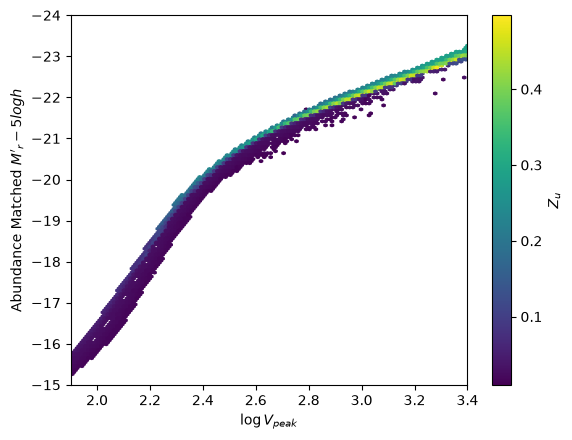

In [19]:
plt.figure()

sc = plt.hexbin(np.log10(mock["Vpeak"]),mock["ABSMAG_R"],C=mock["Z"],gridsize=200,reduce_C_function=np.mean,alpha=1.0,cmap='viridis')

plt.gca().invert_yaxis()
plt.xlabel(r"$\log V_{peak}$")
plt.ylabel(r"Abundance Matched $M'_r-5 log h$")
plt.xlim([1.9,3.4])
plt.ylim([-15,-24])

cbar = plt.colorbar(sc)
cbar.set_label(r"$Z_u$")

# Add vertical dashed line at Vpeak = 100
plt.axvline(100, linestyle='--')

plt.show()

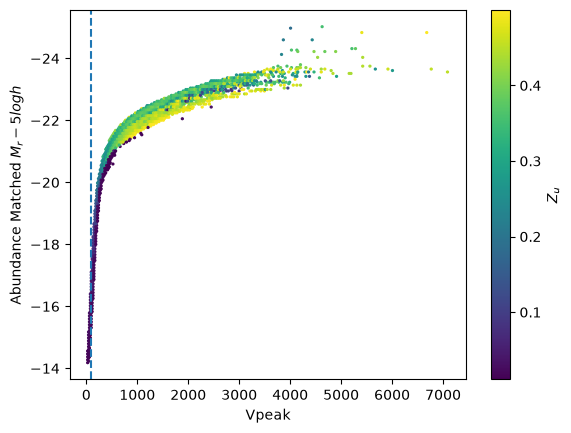

In [20]:
plt.figure()

sc = plt.hexbin(mock["Vpeak"],mock["ABSMAG_RP1"],C=mock["Z"],gridsize=200,reduce_C_function=np.mean,alpha=1.0,cmap='viridis')

plt.gca().invert_yaxis()
plt.xlabel("Vpeak")
plt.ylabel(r"Abundance Matched $M_r-5 log h$")

cbar = plt.colorbar(sc)
cbar.set_label(r"$Z_u$")

# Add vertical dashed line at Vpeak = 100
plt.axvline(100, linestyle='--')

plt.show()

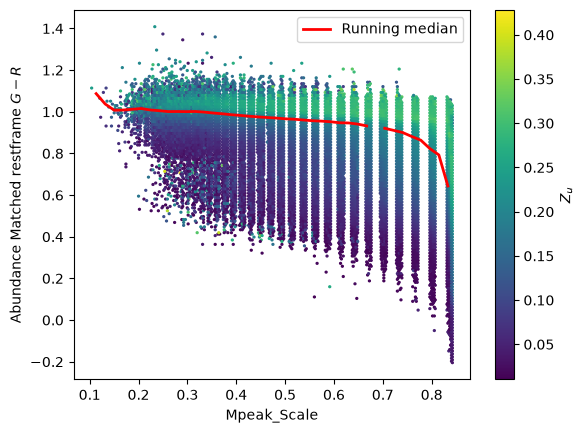

In [21]:

x = mock["Mpeak_Scale"]
y = mock["ABSMAG_GP1"] - mock["ABSMAG_RP1"]

# Your hexbin
hb = plt.hexbin(
    x, y,
    C=mock["Z"],
    gridsize=200,
    reduce_C_function=np.mean,
    alpha=1.0,
    cmap='viridis'
)

# --- Running median ---
# Define bins
nbins = 40
bins = np.linspace(x.min(), x.max(), nbins + 1)

# Digitize
digitized = np.digitize(x, bins)

# Compute median in each bin
bin_centers = 0.5 * (bins[1:] + bins[:-1])
median = np.array([
    np.median(y[digitized == i]) if np.any(digitized == i) else np.nan
    for i in range(1, len(bins))
])

# Plot running median
plt.plot(bin_centers, median, color='red', lw=2, label='Running median')
plt.xlabel(r"Mpeak_Scale")
plt.ylabel(r"Abundance Matched restframe $G-R$")

cbar = plt.colorbar(hb)
cbar.set_label(r"$Z_u$")

plt.legend()
plt.show()

In [22]:
# Read the random catalogue that was used to assign galaxy properties to the mock
ran=Table.read(rancat)

In [23]:
dat=Table.read(datcat)
mask=(dat['reg']==reg)
dat=dat[mask].copy()

In [24]:
def add_contours(ax, x, y, bins=100, levels=6, color='k'):
    # 2D histogram
    H, xedges, yedges = np.histogram2d(x, y, bins=bins)

    # bin centers
    xcent = 0.5 * (xedges[:-1] + xedges[1:])
    ycent = 0.5 * (yedges[:-1] + yedges[1:])

    # transpose for matplotlib convention
    H = H.T

    # contour levels (log spacing works well for galaxy data)
    levs = np.logspace(np.log10(H[H > 0].min()), np.log10(H.max()), levels)

    ax.contour(xcent, ycent, H,
               levels=levs,
               colors=color,
               linewidths=1,
               zorder=3)


In [25]:


def bin_min_reduce(x, y, nbins=1000):
    x = np.asarray(x)
    y = np.asarray(y)

    bins = np.linspace(x.min(), x.max(), nbins + 1)
    idx = np.digitize(x, bins) - 1

    x_min = []
    y_min = []

    for i in range(nbins):
        mask = idx == i
        if np.any(mask):
            j = np.argmin(y[mask])
            x_min.append(x[mask][j])
            y_min.append(y[mask][j])

    return np.array(x_min), np.array(y_min)
    
def lower_bound_polynomial(x, y, degree):
    x = np.asarray(x)
    y = np.asarray(y)

    # Vandermonde matrix (increasing powers: 1, x, x^2, ...)
    X = np.vander(x, N=degree + 1, increasing=True)

    # Objective: maximize sum(poly(x)) → minimize negative
    def objective(c):
        return -np.sum(X @ c)

    # Constraints: X @ c <= y
    constraints = [{
        "type": "ineq",
        "fun": lambda c, row=X[i], yi=y[i]: yi - row @ c
    } for i in range(len(x))]

    # Initial guess
    c0 = np.zeros(degree + 1)

    result = minimize(objective, c0, constraints=constraints)

    if not result.success:
        raise RuntimeError("Optimization failed")

    return result.x  # polynomial coefficients


# Evaluate polynomial
def poly(x, c):
    return np.vander(x, N=len(c), increasing=True) @ c


In [26]:
from scipy.optimize import linprog


def lower_bound_poly_lp(x, y, degree):
    x = np.asarray(x)
    y = np.asarray(y)

    # ✅ CRITICAL: rescale x to avoid numerical issues
    xm = x.mean()
    xs = x.std()
    x_scaled = (x - xm) / xs

    X = np.vander(x_scaled, N=degree + 1, increasing=True)

    # Maximise sum(Xc) → minimise negative
    c_obj = -np.sum(X, axis=0)

    res = linprog(c_obj, A_ub=X, b_ub=y)

    if not res.success:
        raise RuntimeError(res.message)

    return res.x, xm, xs


def poly(x, coeffs, xm, xs):
    x_scaled = (x - xm) / xs
    X = np.vander(x_scaled, N=len(coeffs), increasing=True)
    return X @ coeffs

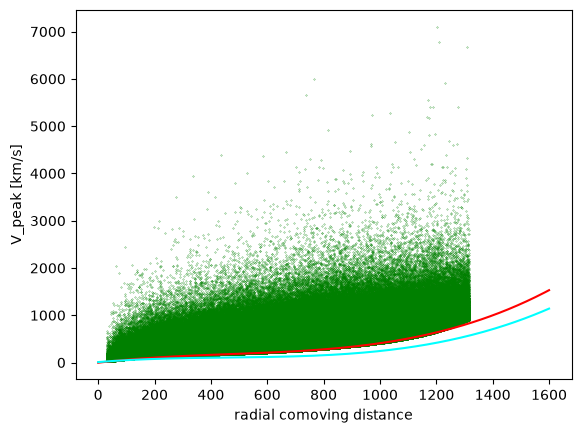

In [27]:
# Scatter plot of Vpeak versus distance for the mock with polynomial fit to the lower envelope

plt.scatter(mock['dist'], mock['Vpeak'],
                s=0.2,
                color='green',
                marker='.',
                rasterized=True,
                zorder=1)


dist_bin, vpeak_bin=bin_min_reduce(mock['dist'], mock['Vpeak'], nbins=100)
#plt.plot(dist_bin,vpeak_bin, color='blue')


coeffs, xm, xs = lower_bound_poly_lp(dist_bin, vpeak_bin, degree=3)

distance = np.linspace(0, 1600, 200)
vpeak_cut_fit = poly(distance, coeffs, xm, xs) 
plt.plot(distance, vpeak_cut_fit, color='red')

vpeak_cut_fit=  20 + 0.397 * distance - 9.0e-04 * distance**2 + 6.0e-07 * distance**3
vpeak_cut_fit=  10 + 0.486 * distance - 9.02e-04 * distance**2 + 6.5e-07 * distance**3
plt.plot(distance, vpeak_cut_fit, color='cyan')

plt.xlabel('radial comoving distance')
plt.ylabel('V_peak [km/s]')
plt.show()




In [28]:
def rescale_to_original(c, xm, xs):
    # Polynomial in (x - xm)/xs
    p = np.poly1d(c[::-1])          # poly in x', highest power first
    u = np.poly1d([1/xs, -xm/xs])   # x' = (x - xm)/xs
    p_full = p(u)                   # substitute

    return p_full.coeffs[::-1]      # back to increasing order

a = rescale_to_original(coeffs, xm, xs)

print("y =", " + ".join(f"{ai:.6g} x^{i}" if i>0 else f"{ai:.6g}"
                       for i, ai in enumerate(a)))

y = -3.33177 + 0.725235 x^1 + -0.00107744 x^2 + 7.64626e-07 x^3


/tmp/ipykernel_247617/1511592150.py:14: UserWarning: The pixel maker ',' is not supported on scatter(); using a finite-sized square instead, which is not necessarily 1 pixel in size. Use the square marker 's' instead to suppress this warning.
  ax.scatter(z_rand, m_rand,


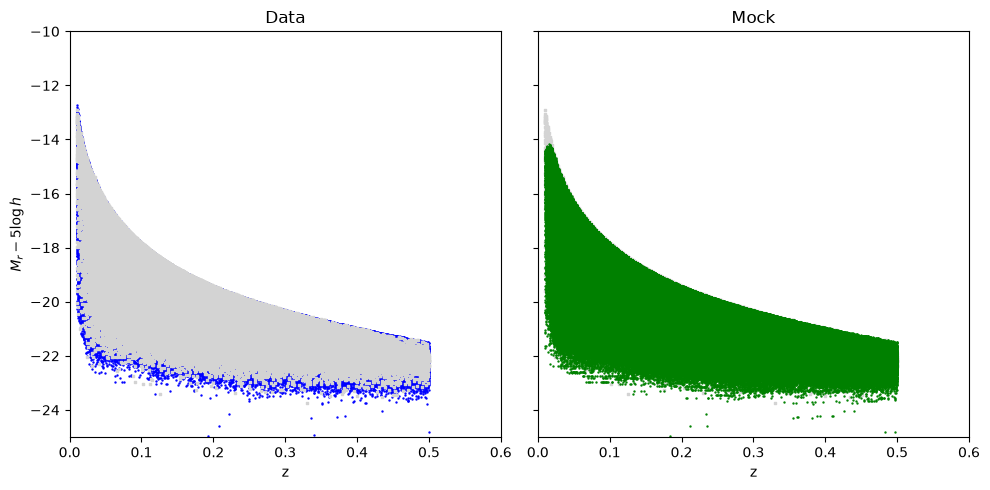

In [29]:

# --- optional: downsample randoms (recommended) ---
rng = np.random.default_rng(42)
n_rand_plot = min(len(ran), 200_000)  # cap for speed
idx = rng.choice(len(ran), size=n_rand_plot, replace=False)

z_rand = ran['Z'][idx]
m_rand = ran['ABSMAG_RP1'][idx]

# --- figure ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

# --- background randoms in both panels ---
for ax in axes:
    ax.scatter(z_rand, m_rand,
               s=1,
               color='lightgray',
               marker=',',          # fastest marker
               rasterized=True,     # huge speed boost
               zorder=1)

# --- LEFT: data ---
axes[0].scatter(dat['Z'], dat['ABSMAG_RP1'],
                s=2,
                color='blue',
                marker='.',
                rasterized=True,
                zorder=0)

axes[0].set_title("Data")

# --- RIGHT: mock ---
axes[1].scatter(mock['Z'], mock['ABSMAG_RP1'],
                s=2,
                color='green',
                marker='.',
                rasterized=True,
                zorder=1)

axes[1].set_title("Mock")

# --- labels ---
for ax in axes:
    ax.set_xlabel('z')
    ax.set_xlim([0,0.6])
    ax.set_ylim([-25,-10])

axes[0].set_ylabel(r'$M_r - 5\log h$')

plt.tight_layout()
plt.show()



/global/common/software/desi/perlmutter/desiconda/20260910-3.1.0/conda/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


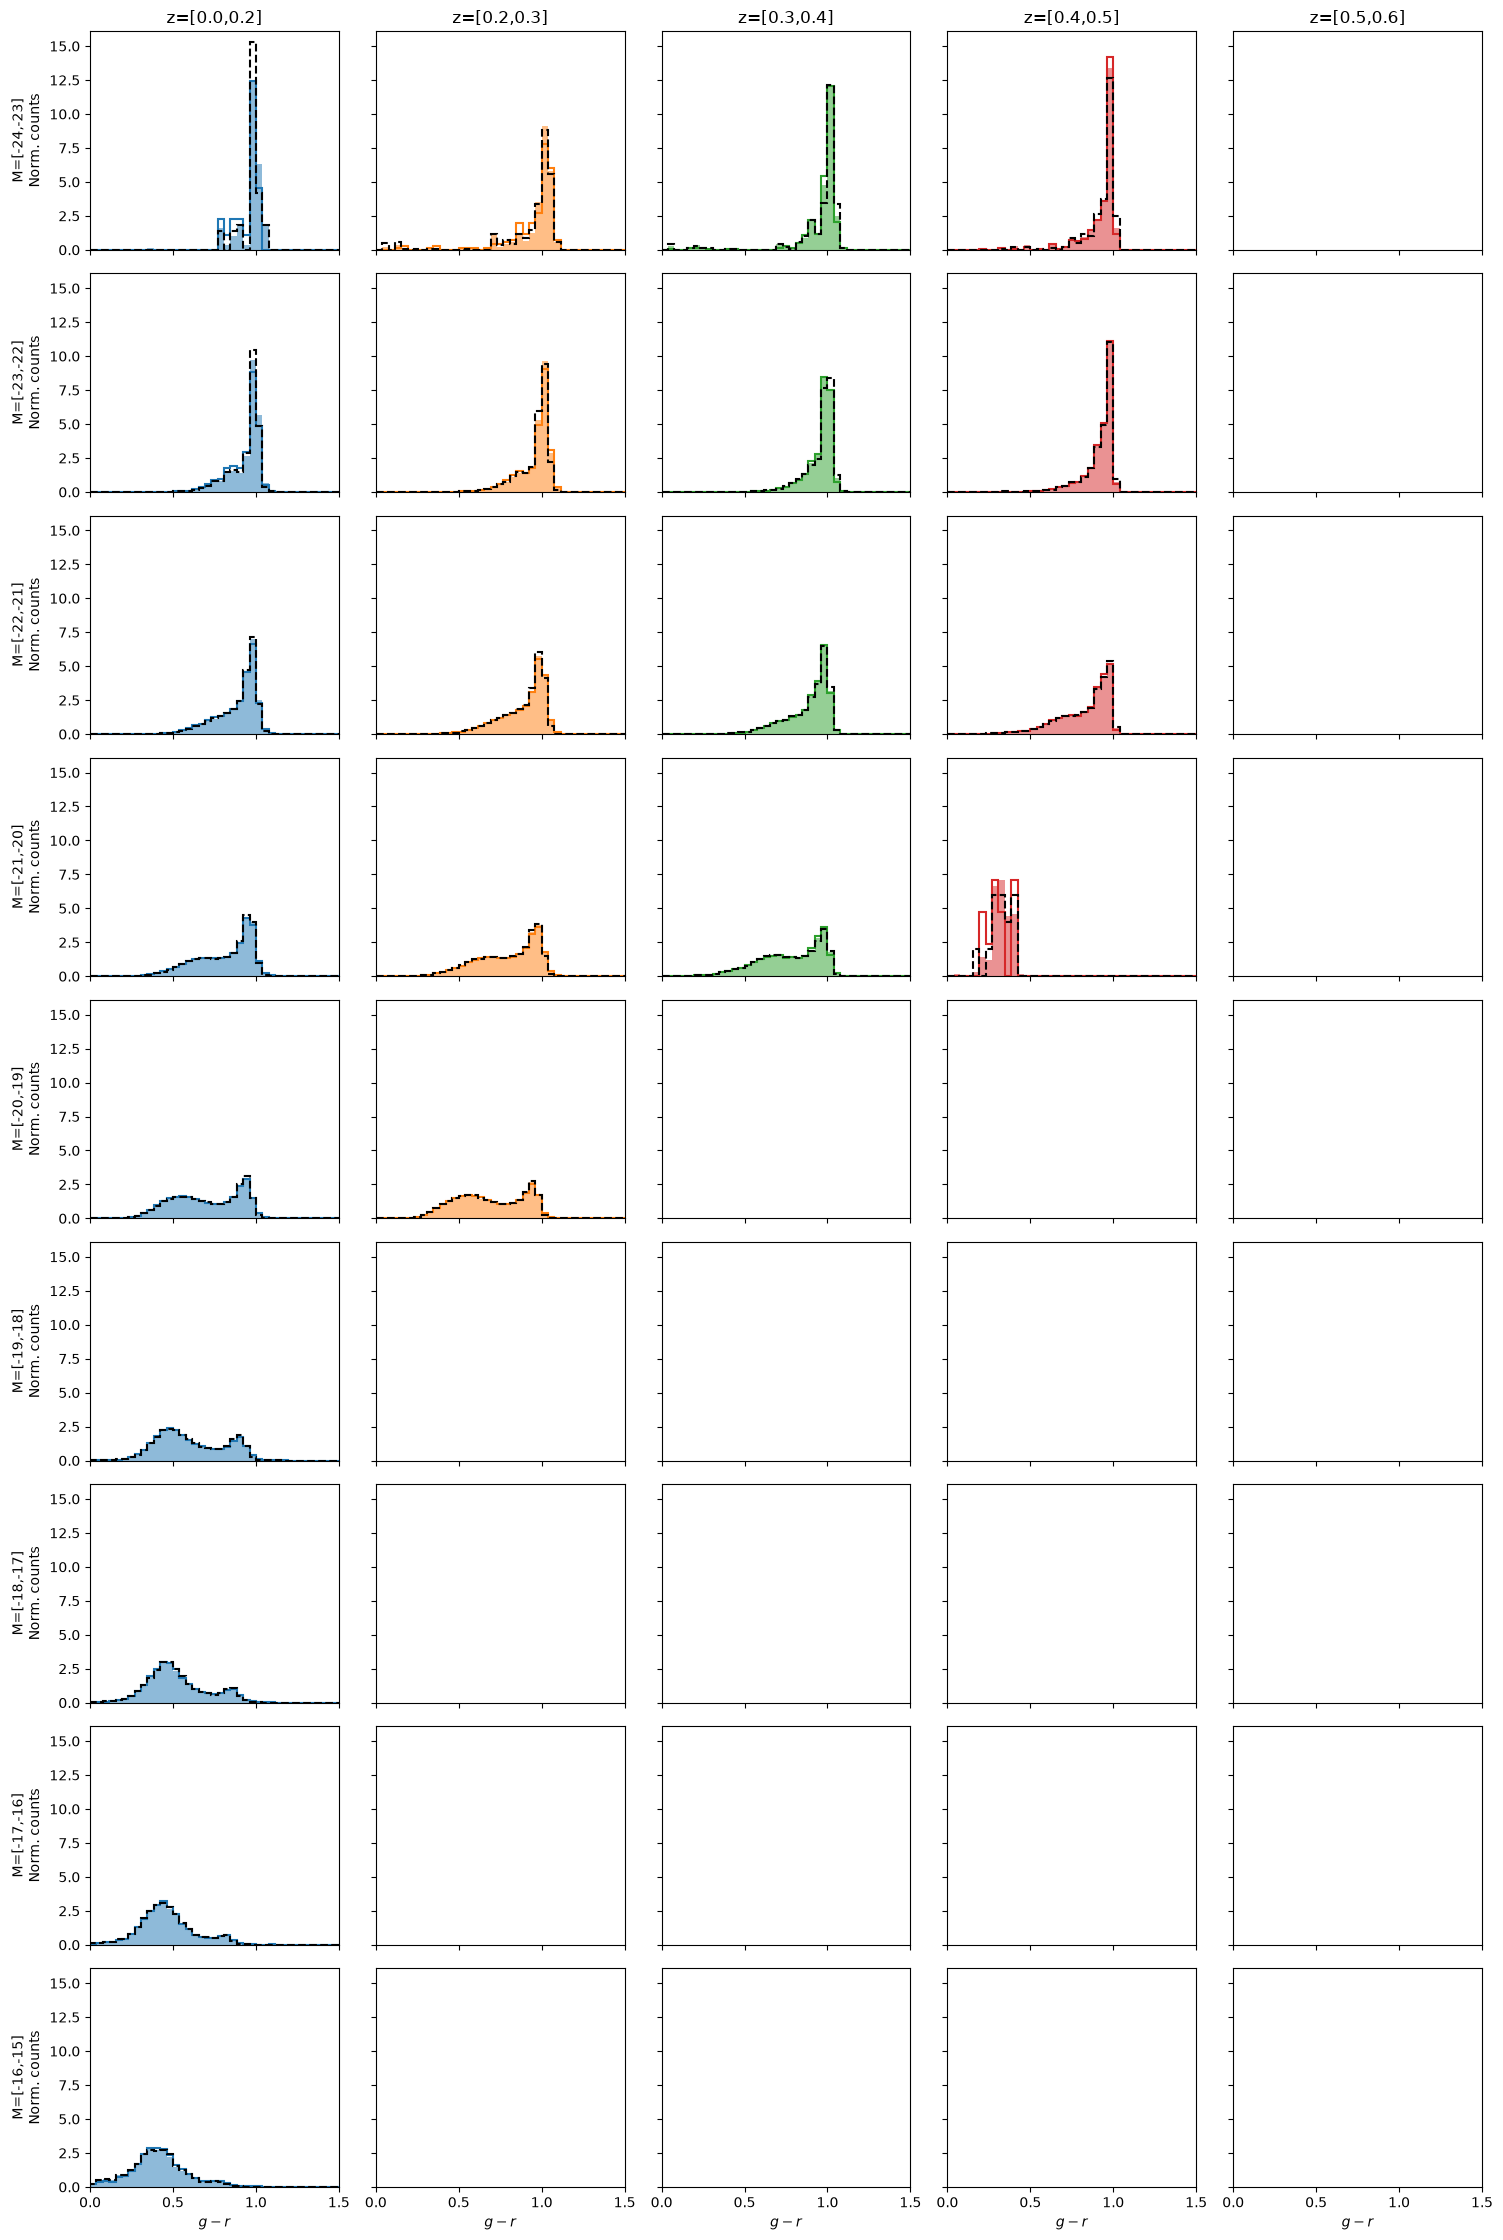

In [30]:
# colors for redshift bins
colors = ['tab:blue', 'tab:orange', 'tab:green',  'tab:red',  'tab:cyan']

# --- optional: downsample randoms (recommended) ---
rng = np.random.default_rng(42)
n_rand_plot = min(len(ran), 200_000)
idx = rng.choice(len(ran), size=n_rand_plot, replace=False)

z_rand = ran['Z'][idx]
m_rand = ran['ABSMAG_RP1'][idx]
col_rand = ran['ABSMAG_GP1'][idx]-ran['ABSMAG_RP1'][idx]


# Or don't sample , keep them all
z_rand = ran['Z']
m_rand = ran['ABSMAG_RP1']
col_rand = ran['ABSMAG_GP1']-ran['ABSMAG_RP1']

# --- redshift bins ---
z_bins = [(0.0, 0.2), (0.2, 0.3), (0.3, 0.4), (0.4, 0.5), (0.5, 0.6)]

# --- magnitude bins ---
mag_bins = np.linspace(-25, -10, 80)

# --- magnitude bins ---
col_bins = np.linspace(0.0, 1.5, 40)

# --- magnitude cuts (define rows) ---
mag_cuts = [
    (-24, -23),
    (-23, -22),
    (-22, -21),
    (-21, -20),
    (-20, -19),
    (-19, -18),
    (-18, -17),
    (-17, -16),
    (-16, -15)
]

n_rows = len(mag_cuts)
n_cols = len(z_bins)

# --- figure ---
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2.5*n_rows),
                         sharex=True, sharey=True)

# ensure axes is 2D even if n_rows=1
if n_rows == 1:
    axes = axes[np.newaxis, :]

# ======================
# MAIN LOOP
# ======================
for j, (mmin, mmax) in enumerate(mag_cuts):  # rows

    for i, ((zmin, zmax), c) in enumerate(zip(z_bins, colors)):  # columns

        ax = axes[j, i]

        # --- selections ---
        sel_data = (
            (dat['Z'] >= zmin) & (dat['Z'] < zmax) &
            (dat['ABSMAG_RP1'] >= mmin) & (dat['ABSMAG_RP1'] < mmax)
        )

        sel_rand = (
            (z_rand >= zmin) & (z_rand < zmax) &
            (m_rand >= mmin) & (m_rand < mmax)
        )

        sel_mock = (
            (mock['Z'] >= zmin) & (mock['Z'] < zmax) &
            (mock['ABSMAG_RP1'] >= mmin) & (mock['ABSMAG_RP1'] < mmax)
        )

        # --- Randoms ---
        ax.hist(col_rand[sel_rand],
                bins=col_bins,
                histtype='stepfilled',
                color=c,
                alpha=0.5,
                density=True,
                zorder=1)

        # --- Data ---
        ax.hist(dat['ABSMAG_GP1'][sel_data] - dat['ABSMAG_RP1'][sel_data],
                bins=col_bins,
                histtype='step',
                linewidth=1.5,
                linestyle='-',
                color=c,
                density=True,
                zorder=2)

        # --- Mock ---
        ax.hist(mock['ABSMAG_GP1'][sel_mock] - mock['ABSMAG_RP1'][sel_mock],
                bins=col_bins,
                histtype='step',
                linewidth=1.5,
                linestyle='--',
                color='black',
                density=True,
                zorder=3)

        # --- titles (top row only) ---
        if j == 0:
            ax.set_title(f'z=[{zmin},{zmax}]')

        # --- row labels (left column only) ---
        if i == 0:
            ax.set_ylabel(f'M=[{mmin},{mmax}]\nNorm. counts')

# --- common x-labels ---
for ax in axes[-1, :]:
    ax.set_xlabel(r'$g - r$')

# --- limits ---
for ax in axes.flatten():
    ax.set_xlim([0, 1.5])

plt.tight_layout()
plt.show()


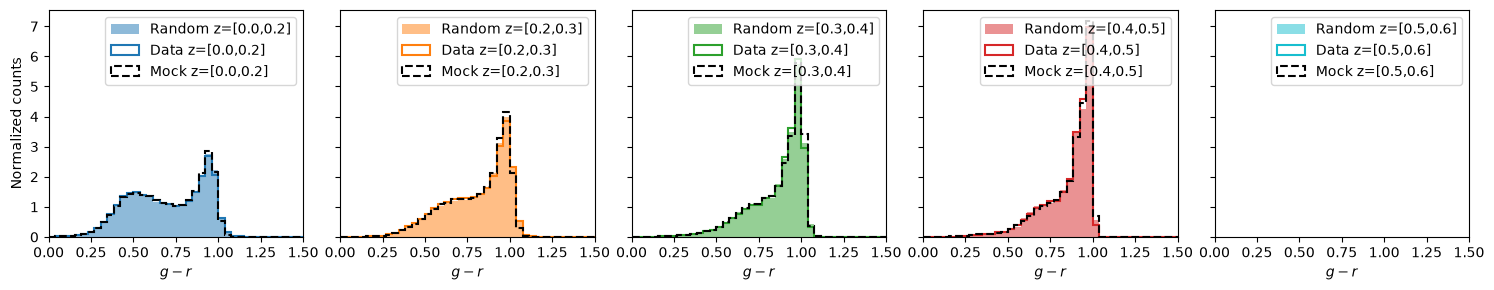

In [31]:

# --- optional: downsample randoms (recommended) ---
rng = np.random.default_rng(42)
n_rand_plot = min(len(ran), 200_000)
idx = rng.choice(len(ran), size=n_rand_plot, replace=False)

z_rand = ran['Z'][idx]
m_rand = ran['ABSMAG_RP1'][idx]
col_rand = ran['ABSMAG_GP1'][idx]-ran['ABSMAG_RP1'][idx]

# --- redshift bins ---
z_bins = [(0.0, 0.2), (0.2, 0.3), (0.3, 0.4), (0.4, 0.5), (0.5, 0.6)]

# --- magnitude bins ---
mag_bins = np.linspace(-25, -10, 80)

# --- magnitude bins ---
col_bins = np.linspace(0.0, 1.5, 40)

# --- figure ---
fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharex=True, sharey=True)
#plt.rcParams.update({
#    'font.size': 14,
#    'axes.labelsize': 16,
#    'axes.titlesize': 18,
#    'xtick.labelsize': 14,
#    'ytick.labelsize': 14,
#    'legend.fontsize': 14
#})



# colors for redshift bins
colors = ['tab:blue', 'tab:orange', 'tab:green',  'tab:red',  'tab:cyan']

# ======================
# LEFT: Data vs Random
# ======================
i=-1
for (zmin, zmax), c in zip(z_bins, colors):
    i+=1
    sel_data = (dat['Z'] >= zmin) & (dat['Z'] < zmax)
    sel_rand = (z_rand >= zmin) & (z_rand < zmax)
    sel_mock = (mock['Z'] >= zmin) & (mock['Z'] < zmax)
    
    # --- Randoms (background) ---
    axes[i].hist(col_rand[sel_rand],
                 bins=col_bins,
                 histtype='stepfilled',
                 color=c,
                 alpha=0.5,
                 density=True,
                 zorder=1,label=f"Random z=[{zmin},{zmax}]")

    # --- Data (foreground, solid line) ---
    axes[i].hist(dat['ABSMAG_GP1'][sel_data]-dat['ABSMAG_RP1'][sel_data],
                 bins=col_bins,
                 histtype='step',
                 linewidth=1.5,
                 linestyle='-',
                 color=c,
                 density=True,
                 label=f"Data z=[{zmin},{zmax}]",
                 zorder=2)


    # --- Mock (foreground, dashed line) ---
    axes[i].hist(mock['ABSMAG_GP1'][sel_mock]-mock['ABSMAG_RP1'][sel_mock],
                 bins=col_bins,
                 histtype='step',
                 linewidth=1.5,
                 linestyle='--',
                 color='black',
                 density=True,
                 label=f"Mock z=[{zmin},{zmax}]",
                 zorder=3)


# --- labels ---
for ax in axes:
    ax.set_xlabel(r'$g-r$')
    ax.legend()

axes[0].set_ylabel('Normalized counts')
axes[0].set_xlim([0,1.5])
plt.tight_layout()
plt.savefig("colours.pdf", dpi=600, bbox_inches="tight")
plt.show()



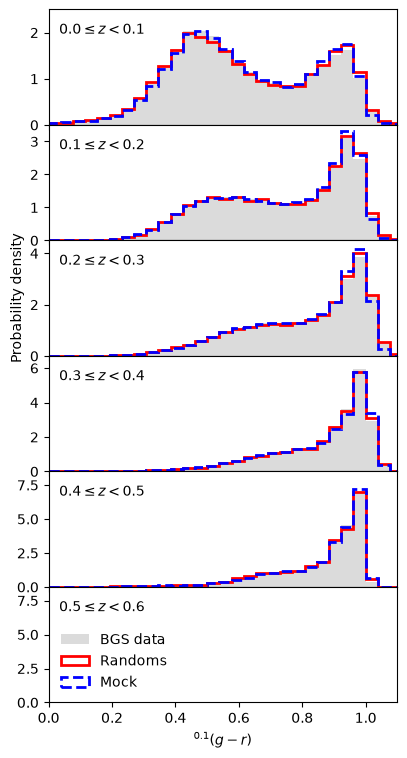

In [32]:
# --- optional: downsample randoms (recommended) ---
rng = np.random.default_rng(42)
n_rand_plot = min(len(ran), 200_000)
idx = rng.choice(len(ran), size=n_rand_plot, replace=False)

z_rand = ran['Z'][idx]
col_rand = ran['ABSMAG_GP1'][idx] - ran['ABSMAG_RP1'][idx]

# --- redshift bins ---
z_bins = [
    (0.0, 0.1),
    (0.1, 0.2),
    (0.2, 0.3),
    (0.3, 0.4),
    (0.4, 0.5),
    (0.5, 0.6)
]

# --- colour bins ---
col_bins = np.linspace(0.0, 1.5, 40)

fig, axes = plt.subplots(
    len(z_bins), 1,
    figsize=(4.5, 9),
    sharex=True
)

fig.subplots_adjust(hspace=0.0)

for i, (zmin, zmax) in enumerate(z_bins):

    ax = axes[i]

    sel_data = (dat['Z'] >= zmin) & (dat['Z'] < zmax)
    sel_rand = (z_rand >= zmin) & (z_rand < zmax)
    sel_mock = (mock['Z'] >= zmin) & (mock['Z'] < zmax)

    # -----------------------------
    # BGS data (grey shaded)
    # -----------------------------
    ax.hist(
        dat['ABSMAG_GP1'][sel_data]
        - dat['ABSMAG_RP1'][sel_data],
        bins=col_bins,
        density=True,
        histtype='stepfilled',
        color='lightgrey',
        alpha=0.8,
        label='BGS data' if i == 0 else None
    )

    # -----------------------------
    # Randoms (red solid)
    # -----------------------------
    ax.hist(
        col_rand[sel_rand],
        bins=col_bins,
        density=True,
        histtype='step',
        color='red',
        linewidth=2,
        label='Randoms' if i == 0 else None
    )

    # -----------------------------
    # Mock (blue dashed)
    # -----------------------------
    ax.hist(
        mock['ABSMAG_GP1'][sel_mock]
        - mock['ABSMAG_RP1'][sel_mock],
        bins=col_bins,
        density=True,
        histtype='step',
        color='blue',
        linestyle='--',
        linewidth=2,
        label='Mock' if i == 0 else None
    )

    # Redshift label inside panel
    ax.text(
        0.03, 0.88,
        rf'${zmin:.1f}\leq z<{zmax:.1f}$',
        transform=ax.transAxes,
        ha='left',
        va='top'
    )


axes[0].set_ylim(0, 2.5)
axes[1].set_ylim(0, 3.5)
axes[2].set_ylim(0, 4.5)
axes[3].set_ylim(0, 6.7)
axes[4].set_ylim(0, 8.5)
axes[5].set_ylim(0, 8.5)

# labels
axes[2].set_ylabel('Probability density')
axes[-1].set_xlabel(r'${}^{0.1}(g-r)$')





handles, labels = axes[0].get_legend_handles_labels()

axes[-1].legend(
    handles,
    labels,
    frameon=False,
    loc='lower left'
)

axes[0].set_xlim(0, 1.1)

plt.savefig(
    "colours.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

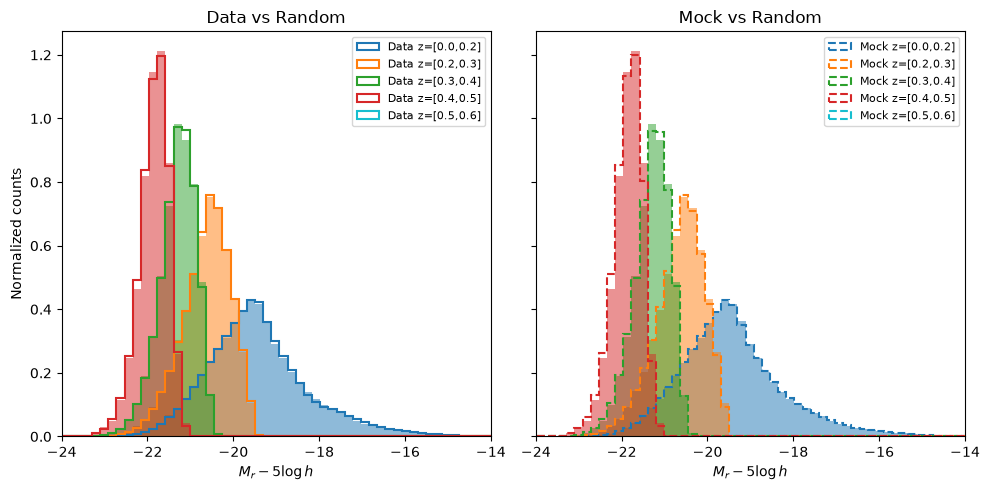

In [33]:

# --- optional: downsample randoms (recommended) ---
rng = np.random.default_rng(42)
n_rand_plot = min(len(ran), 200_000)
idx = rng.choice(len(ran), size=n_rand_plot, replace=False)

z_rand = ran['Z'][idx]
m_rand = ran['ABSMAG_RP1'][idx]

# --- redshift bins ---
z_bins = [(0.0, 0.2), (0.2, 0.3), (0.3, 0.4), (0.4, 0.5), (0.5, 0.6)]

# --- magnitude bins ---
mag_bins = np.linspace(-25, -10, 80)

# --- figure ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

# colors for redshift bins
colors = ['tab:blue', 'tab:orange', 'tab:green',  'tab:red',  'tab:cyan']

# ======================
# LEFT: Data vs Random
# ======================
for (zmin, zmax), c in zip(z_bins, colors):

    sel_data = (dat['Z'] >= zmin) & (dat['Z'] < zmax)
    sel_rand = (z_rand >= zmin) & (z_rand < zmax)

    # --- Randoms (background) ---
    axes[0].hist(m_rand[sel_rand],
                 bins=mag_bins,
                 histtype='stepfilled',
                 color=c,
                 alpha=0.5,
                 density=True,
                 zorder=1)

    # --- Data (foreground, solid line) ---
    axes[0].hist(dat['ABSMAG_RP1'][sel_data],
                 bins=mag_bins,
                 histtype='step',
                 linewidth=1.5,
                 linestyle='-',
                 color=c,
                 density=True,
                 label=f"Data z=[{zmin},{zmax}]",
                 zorder=2)

axes[0].set_title("Data vs Random")
axes[0].legend(fontsize=8)

# ======================
# RIGHT: Mock vs Random
# ======================
for (zmin, zmax), c in zip(z_bins, colors):

    sel_mock = (mock['Z'] >= zmin) & (mock['Z'] < zmax)
    sel_rand = (z_rand >= zmin) & (z_rand < zmax)

    # --- Randoms (background) ---
    axes[1].hist(m_rand[sel_rand],
                 bins=mag_bins,
                 histtype='stepfilled',
                 color=c,
                 alpha=0.5,
                 density=True,
                 zorder=1)

    # --- Mock (foreground, dashed line) ---
    axes[1].hist(mock['ABSMAG_RP1'][sel_mock],
                 bins=mag_bins,
                 histtype='step',
                 linewidth=1.5,
                 linestyle='--',
                 color=c,
                 density=True,
                 label=f"Mock z=[{zmin},{zmax}]",
                 zorder=2)

axes[1].set_title("Mock vs Random")
axes[1].legend(fontsize=8)

# --- labels ---
for ax in axes:
    ax.set_xlabel(r'$M_r - 5\log h$')

axes[0].set_ylabel('Normalized counts')
axes[0].set_xlim([-24,-14])
plt.tight_layout()
plt.show()



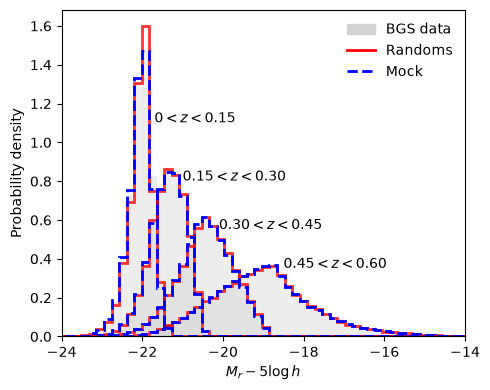

In [34]:
# --- optional: downsample randoms ---
rng = np.random.default_rng(42)

n_rand_plot = min(len(ran), 200_000)

idx = rng.choice(
    len(ran),
    size=n_rand_plot,
    replace=False
)

z_rand = ran['Z'][idx]
m_rand = ran['ABSMAG_RP1'][idx]

# --- redshift bins ---
z_bins = [
    (0.0, 0.15),
    (0.15, 0.30),
    (0.30, 0.45),
    (0.45, 0.60)
]

# --- magnitude bins ---
mag_bins = np.linspace(-25, -14, 60)

fig, ax = plt.subplots(
    figsize=(5,4)
)

colors = [
    'tab:blue',
    'tab:orange',
    'tab:green',
    'tab:red'
]

for (zmin, zmax), c in zip(z_bins, colors):

    sel_data = (
        (dat['Z'] >= zmin)
        & (dat['Z'] < zmax)
    )

    sel_rand = (
        (z_rand >= zmin)
        & (z_rand < zmax)
    )

    sel_mock = (
        (mock['Z'] >= zmin)
        & (mock['Z'] < zmax)
    )

    #data
    ax.hist(
        dat['ABSMAG_RP1'][sel_data],
        bins=mag_bins,
        density=True,
        histtype='stepfilled',
        color='lightgrey',
        alpha=0.4
    )
    # Randoms
    ax.hist(
        m_rand[sel_rand],
        bins=mag_bins,
        density=True,
        histtype='step',
        color='red',
        linewidth=2,
        alpha=0.8
    )

    # Mock
    ax.hist(
        mock['ABSMAG_RP1'][sel_mock],
        bins=mag_bins,
        density=True,
        histtype='step',
        color='blue',
        linestyle='--',
        linewidth=2,
        label=rf'${zmin:.2f}\leq z<{zmax:.2f}$'
    )

ax.set_xlabel(r'$M_r - 5\log h$')
ax.set_ylabel('Probability density')

ax.set_xlim(-24, -14)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

handles = [
    Patch(facecolor='lightgrey', edgecolor='lightgrey', label='BGS data'),
    Line2D([0],[0], color='red', lw=2, label='Randoms'),
    Line2D([0],[0], color='blue', lw=2, ls='--', label='Mock')
]


ax.text(-21.7, 1.10, r'$0<z<0.15$')
ax.text(-21.0, 0.80, r'$0.15<z<0.30$')
ax.text(-20.1, 0.55, r'$0.30<z<0.45$')
ax.text(-18.5, 0.35, r'$0.45<z<0.60$')


ax.legend(
    handles=handles,
    frameon=False,
    loc='upper right'
)


plt.tight_layout()

plt.savefig(
    "magnitudes.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [35]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

handles = [
    Patch(facecolor='lightgrey', edgecolor='lightgrey', label='BGS data'),
    Line2D([0],[0], color='red', lw=2, label='Randoms'),
    Line2D([0],[0], color='blue', lw=2, ls='--', label='Mock')
]

ax.legend(
    handles=handles,
    frameon=False,
    loc='upper right'
)

/tmp/ipykernel_247617/100551392.py:17: UserWarning: The pixel maker ',' is not supported on scatter(); using a finite-sized square instead, which is not necessarily 1 pixel in size. Use the square marker 's' instead to suppress this warning.
  ax.scatter(z_rand, r_rand,


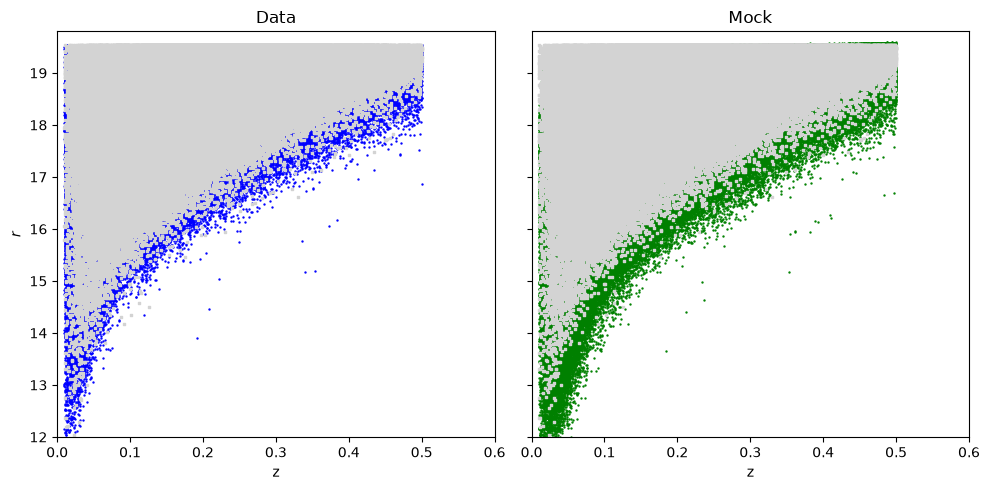

In [36]:
#magnitude redshift distribution


# --- optional: downsample randoms (recommended) ---
rng = np.random.default_rng(42)
n_rand_plot = min(len(ran), 200_000)  # cap for speed
idx = rng.choice(len(ran), size=n_rand_plot, replace=False)

z_rand = ran['Z'][idx]
r_rand = ran['rmag'][idx]

# --- figure ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

# --- background randoms in both panels ---
for ax in axes:
    ax.scatter(z_rand, r_rand,
               s=1,
               color='lightgray',
               marker=',',          # fastest marker
               rasterized=True,     # huge speed boost
               zorder=1)

# --- LEFT: data ---
axes[0].scatter(dat['Z'], dat['rmag'],
                s=2,
                color='blue',
                marker='.',
                rasterized=True,
                zorder=0)

axes[0].set_title("Data")

# --- RIGHT: mock ---
axes[1].scatter(mock['Z'], mock['rmag'],
                s=2,
                color='green',
                marker='.',
                rasterized=True,
                zorder=0)

axes[1].set_title("Mock")

# --- labels ---
for ax in axes:
    ax.set_xlabel('z')
    ax.set_xlim([0,0.6])
    ax.set_ylim([12,19.8])

axes[0].set_ylabel(r'$r$')

plt.tight_layout()
plt.show()



/tmp/ipykernel_247617/3238310269.py:17: UserWarning: The pixel maker ',' is not supported on scatter(); using a finite-sized square instead, which is not necessarily 1 pixel in size. Use the square marker 's' instead to suppress this warning.
  ax.scatter(z_rand, r_rand,


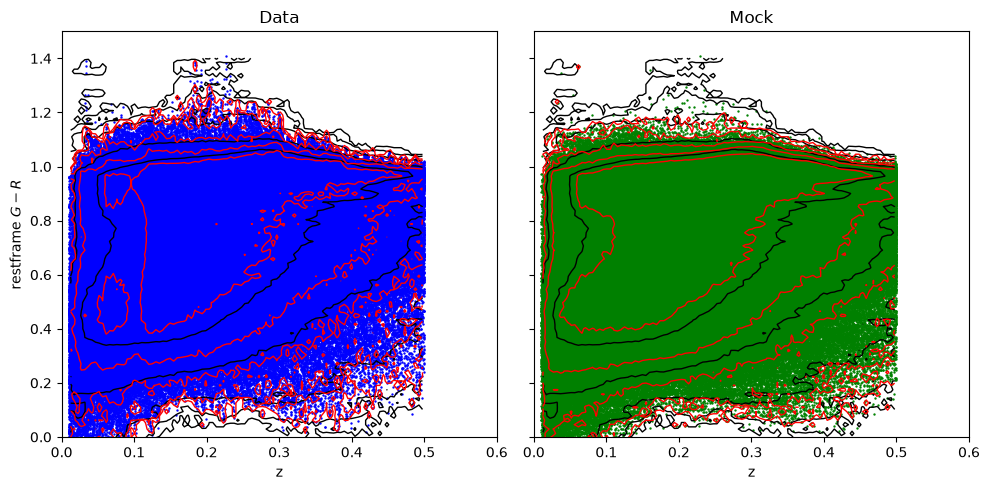

In [37]:
#colour redshift distribution with option absolute magnitude cut for the contours
absmagcut=-10

# --- optional: downsample randoms (recommended) ---
rng = np.random.default_rng(42)
n_rand_plot = min(len(ran), 200_000)  # cap for speed
idx = rng.choice(len(ran), size=n_rand_plot, replace=False)

z_rand = ran['Z'][idx]
col_rand = ran['ABSMAG_GP1'][idx]-ran['ABSMAG_RP1'][idx]

# --- figure ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

# --- background randoms in both panels ---
for ax in axes:
    ax.scatter(z_rand, r_rand,
               s=1,
               color='lightgray',
               marker=',',          # fastest marker
               rasterized=True,     # huge speed boost
               zorder=1)
    mask=(ran['ABSMAG_RP1']<absmagcut)
    add_contours(ax, ran['Z'][mask], ran['ABSMAG_GP1'][mask]-ran['ABSMAG_RP1'][mask], color='black')

# --- LEFT: data ---
axes[0].scatter(dat['Z'], dat['ABSMAG_GP1']-dat['ABSMAG_RP1'],
                s=2,
                color='blue',
                marker='.',
                rasterized=True,
                zorder=0)
mask=(dat['ABSMAG_RP1']<absmagcut)
add_contours(axes[0], dat['Z'][mask], dat['ABSMAG_GP1'][mask]-dat['ABSMAG_RP1'][mask], color='red')

axes[0].set_title("Data")

# --- RIGHT: mock ---
axes[1].scatter(mock['Z'], mock['ABSMAG_GP1']-mock['ABSMAG_RP1'],
                s=2,
                color='green',
                marker='.',
                rasterized=True,
                zorder=1)

mask=(mock['ABSMAG_RP1']<absmagcut)
add_contours(axes[1], mock['Z'][mask], mock['ABSMAG_GP1'][mask]-mock['ABSMAG_RP1'][mask], color='red')

axes[1].set_title("Mock")

# --- labels ---
for ax in axes:
    ax.set_xlabel('z')
    ax.set_xlim([0,0.6])
    ax.set_ylim([0.0,1.5])

axes[0].set_ylabel(r'restframe $G-R$')

plt.tight_layout()
plt.show()



Using healpix map with NSIDE=32 and pixel area 3.357 sq.deg.


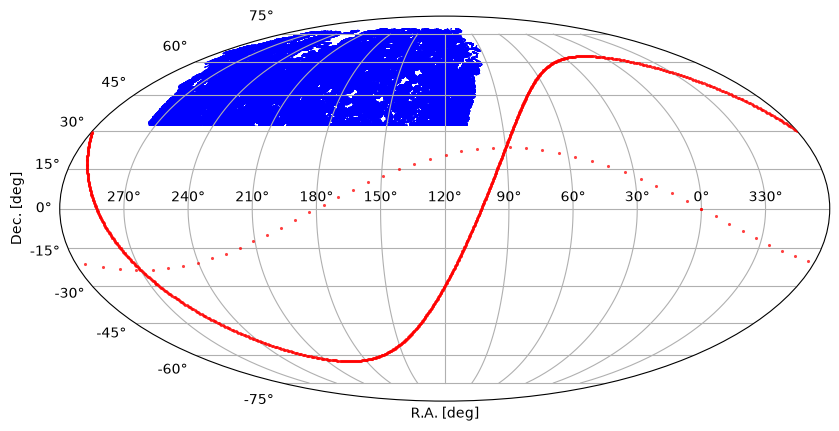

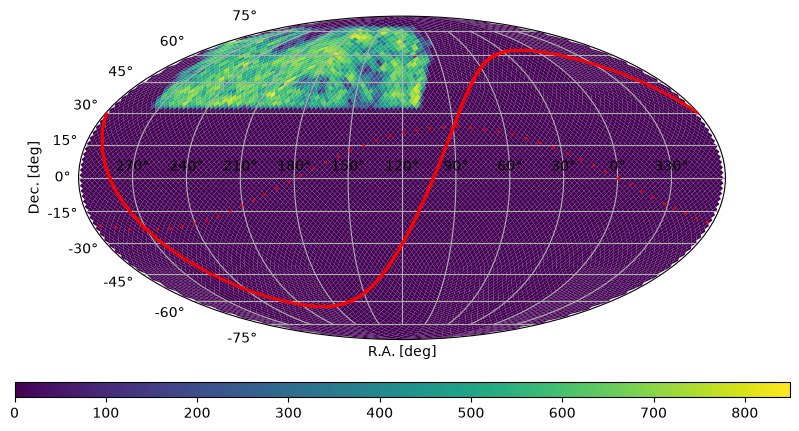

In [38]:
ca.sky_plot(dat,reg)

Using healpix map with NSIDE=32 and pixel area 3.357 sq.deg.


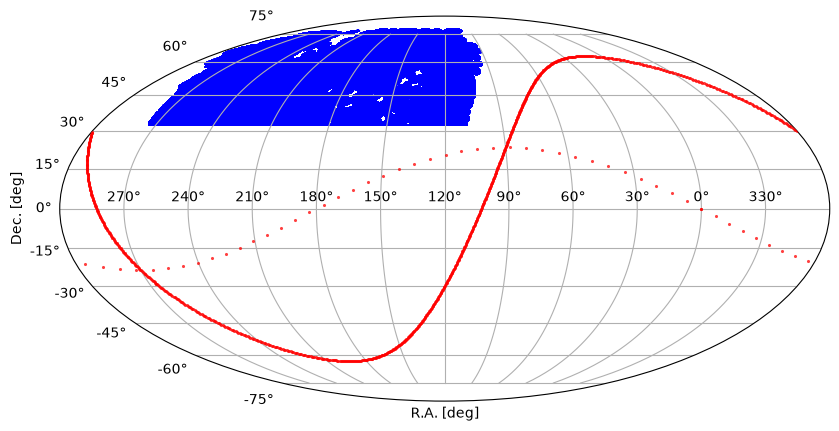

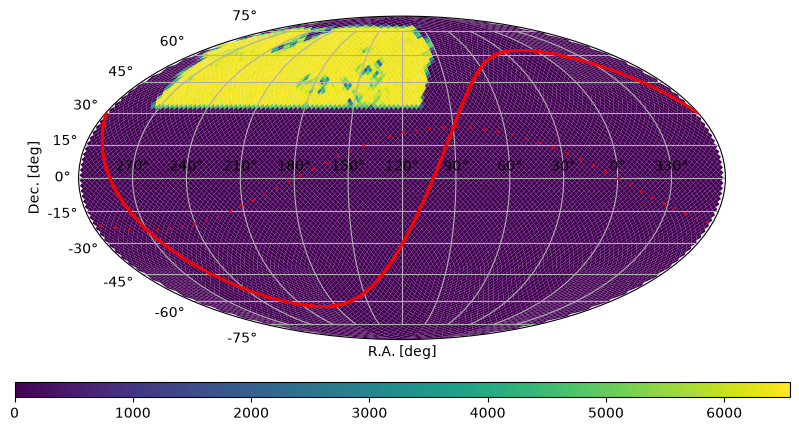

In [39]:
ca.sky_plot(ran,reg)

Using healpix map with NSIDE=32 and pixel area 3.357 sq.deg.


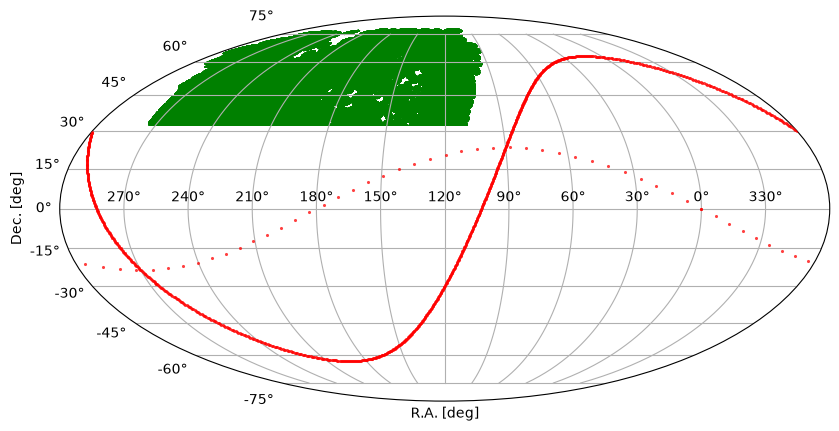

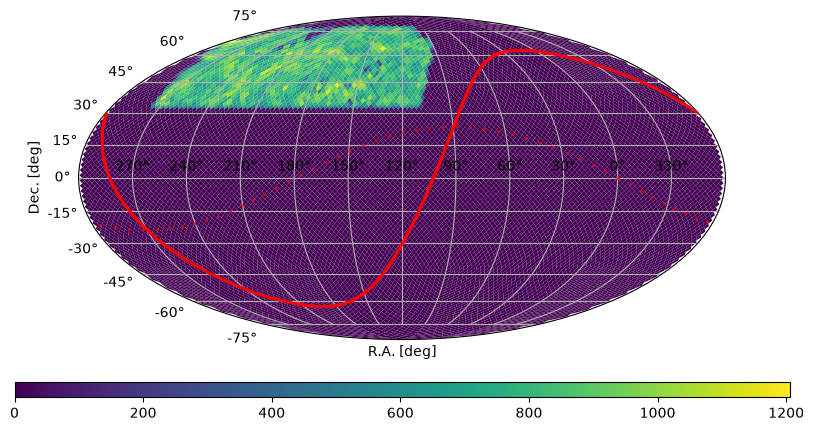

In [40]:
ca.sky_plot(mock,reg)

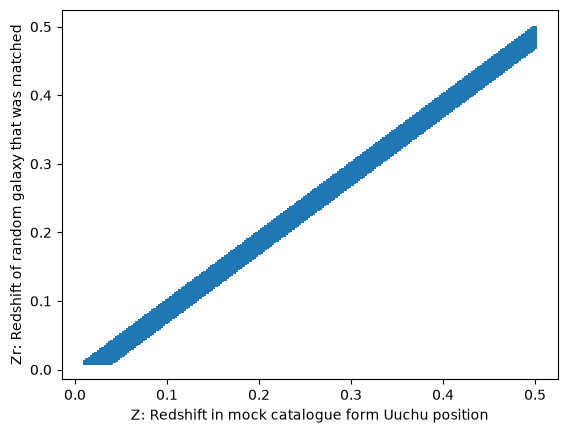

In [41]:
# Plots of matched objects

plt.scatter(mock["Z"],mock["Zr"], s=1, alpha=1.0)
plt.xlabel("Z: Redshift in mock catalogue form Uuchu position")
plt.ylabel("Zr: Redshift of random galaxy that was matched")
plt.show()

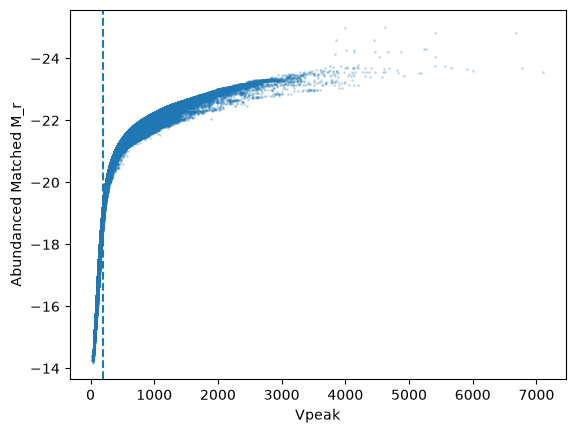

In [42]:
# Plots of matched objects
plt.scatter(mock["Vpeak"], mock["ABSMAG_RP1"], s=1, alpha=0.2)

# Add vertical dashed line at Vpeak = 200
plt.axvline(200, linestyle='--')

plt.gca().invert_yaxis()
plt.xlabel("Vpeak")
plt.ylabel("Abundanced Matched M_r")
plt.show()


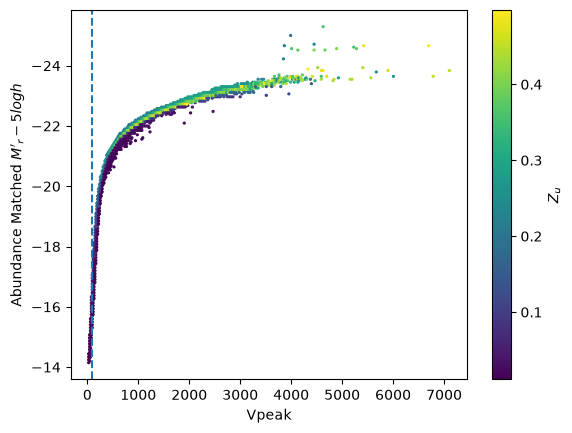

In [43]:
plt.figure()

sc = plt.hexbin(mock["Vpeak"],mock["ABSMAG_R"],C=mock["Z"],gridsize=200,reduce_C_function=np.mean,alpha=1.0,cmap='viridis')

plt.gca().invert_yaxis()
plt.xlabel("Vpeak")
plt.ylabel(r"Abundance Matched $M'_r-5 log h$")

cbar = plt.colorbar(sc)
cbar.set_label(r"$Z_u$")

# Add vertical dashed line at Vpeak = 100
plt.axvline(100, linestyle='--')

plt.show()

In [44]:
#Cone plot
def cone_plots(dat,mock,regions):
    """This is hardwired to produce two particular cone plots but could be adapted"""
    for reg in regions:
        if "reg" in dat.colnames:
            regmask = (dat['reg']==reg)
        else:
            regmask = (dat['rmag']<100) #always true
        Sel=ca.selection(reg) # define selection parameters for this region
        # Selection to remove stars and impose chosen magnitude limit
        if (reg=='S'):
            datmask = (regmask) & (dat['Z'] > Sel['zmin']) & (dat['rmag'] < Sel['faint']) &  (dat['DEC'] > -5)  &  (dat['DEC'] < 0)  &  (dat['RA'] > 180.0) &  (dat['RA'] < 280.0)
            mockmask = (mock['Z'] > Sel['zmin']) & (mock['rmag'] < Sel['faint']) &  (mock['DEC'] > -5)  &  (mock['DEC'] < 0)  &  (mock['RA'] > 180.0) &  (mock['RA'] < 280.0)
        else:
            datmask = (regmask) & (dat['Z'] > Sel['zmin']) & (dat['rmag'] < Sel['faint']) &  (dat['DEC'] > 30.0)  &  (dat['DEC'] < 35.0)  &  (dat['RA'] > 180.0) &  (dat['RA'] < 280.0)
            mockmask = (mock['Z'] > Sel['zmin']) & (mock['rmag'] < Sel['faint']) &  (mock['DEC'] > 30.0)  &  (mock['DEC'] < 35.0)  &  (mock['RA'] > 180.0) &  (mock['RA'] < 280.0)
             
        print(np.count_nonzero(datmask), np.count_nonzero(mockmask),' points in the cone plots')
        
        offset=+1.5*np.pi/2.0


        #fig, axes = plt.subplots(2, 1,figsize=(4.5, 8),sharex=True,sharey=True)

        #ax_data = axes[0]
        #ax_mock = axes[1]
        
        x=dat[datmask]['Z']*np.sin(np.radians(dat[datmask]['RA'])+offset)
        y=dat[datmask]['Z']*np.cos(np.radians(dat[datmask]['RA'])+offset)
        plt.axis('equal')
        plt.axis('off')
        plt.scatter(x,y,color='black',s=0.25, marker='.', linewidths=0)
        ra_min=dat[datmask]['RA'].min()
        ra_max=dat[datmask]['RA'].max()
        print('RA range:',ra_min,ra_max)
        ra=np.linspace(ra_min,ra_max,100)
        z_max=dat[datmask]['Z'].max()
        frame_x=np.concatenate((np.array([0]),z_max*np.sin(np.radians(ra)+offset),np.array([0])))
        frame_y=np.concatenate((np.array([0]),z_max*np.cos(np.radians(ra)+offset),np.array([0])))
        plt.plot(frame_x,frame_y,color='violet')
        
        
        x=mock[mockmask]['Z']*np.sin(np.radians(mock[mockmask]['RA'])+offset)
        y=mock[mockmask]['Z']*np.cos(np.radians(mock[mockmask]['RA'])+offset)
        plt.axis('equal')
        plt.axis('off')
        plt.scatter(x,y,color='blue',s=0.25, marker='.', linewidths=0)
        ra_min=mock[mockmask]['RA'].min()
        ra_max=mock[mockmask]['RA'].max()
        print('RA range:',ra_min,ra_max)
        ra=np.linspace(ra_min,ra_max,100)
        z_max=mock[mockmask]['Z'].max()
        frame_x=np.concatenate((np.array([0]),z_max*np.sin(np.radians(ra)+offset),np.array([0])))
        frame_y=np.concatenate((np.array([0]),z_max*np.cos(np.radians(ra)+offset),np.array([0])))
        plt.plot(frame_x,frame_y,color='violet')
        
        
        
        plt.tight_layout()

        plt.savefig(
            "wedges.pdf",
            dpi=600,
            bbox_inches="tight"
        )

    del x,y,ra # tidy up
    return



126394 170994  points in the cone plots
RA range: 180.00358065640387 275.5258877726827
RA range: 180.00042880606145 275.58521745559455


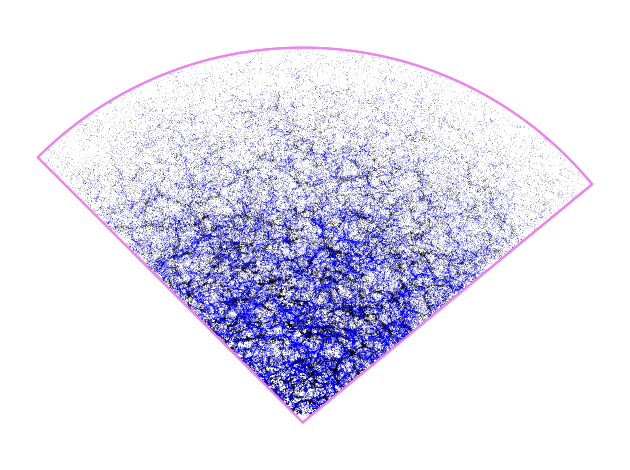

In [45]:
cone_plots(dat,mock,reg)

In [46]:
def cone_plots(dat, mock, regions):

   

  # fixed wedge geometry
    ra_min = 180.0
    ra_max = 275.0
    z_max = 0.50
    
    for reg in regions:

        if "reg" in dat.colnames:
            regmask = (dat['reg'] == reg)
        else:
            regmask = np.ones(len(dat), dtype=bool)

        Sel = ca.selection(reg)

        if reg == 'S':
            datmask = (
                regmask
                & (dat['Z'] > Sel['zmin'])
                & (dat['Z'] < z_max)
                & (dat['rmag'] < Sel['faint'])
                & (dat['DEC'] > -5)
                & (dat['DEC'] < 0)
                & (dat['RA'] > 180)
                & (dat['RA'] < 275)
            )

            mockmask = (
                (mock['Z'] > Sel['zmin'])
                & (mock['Z'] < z_max)
                & (mock['rmag'] < Sel['faint'])
                & (mock['DEC'] > -5)
                & (mock['DEC'] < 0)
                & (mock['RA'] > 180)
                & (mock['RA'] < 275)
            )

        else:

            datmask = (
                regmask
                & (dat['Z'] > Sel['zmin'])
                & (dat['Z'] < z_max)
                & (dat['rmag'] < Sel['faint'])
                & (dat['DEC'] > 30)
                & (dat['DEC'] < 35)
                & (dat['RA'] > 180)
                & (dat['RA'] < 275)
            )

            mockmask = (
                (mock['Zobs'] > Sel['zmin'])
                & (mock['Zobs'] < z_max)
                & (mock['rmag'] < Sel['faint'])
                & (mock['DEC'] > 30)
                & (mock['DEC'] < 35)
                & (mock['RA'] > 180)
                & (mock['RA'] < 275)
            )

        print(
            np.count_nonzero(datmask),
            np.count_nonzero(mockmask),
            'points in cone plots'
        )

        fig, axes = plt.subplots(
            2, 1,
            figsize=(4.5,6.0),
            sharex=True,
            sharey=True
        )

        offset = 1.5 * np.pi / 2.0

      

        ra = np.linspace(ra_min, ra_max, 200)

        frame_x = np.concatenate(
            ([0],
             z_max * np.sin(np.radians(ra) + offset),
             [0])
        )

        frame_y = np.concatenate(
            ([0],
             z_max * np.cos(np.radians(ra) + offset),
             [0])
        )

        #
        # DATA PANEL
        #

        x = (
            dat['Z'][datmask]
            * np.sin(np.radians(dat['RA'][datmask]) + offset)
        )

        y = (
            dat['Z'][datmask]
            * np.cos(np.radians(dat['RA'][datmask]) + offset)
        )

        axes[0].scatter(
            x, y,
            color='black',
            s=0.1,
            marker='.',
            linewidths=0
        )

        axes[0].plot(
            frame_x,
            frame_y,
            color='0.6',
            lw=1
        )

        axes[0].text(
            0.00,
            0.9,
            'BGS Data',
            transform=axes[0].transAxes,
            va='top'
        )

        #
        # MOCK PANEL
        #

        x = (
            mock['Zobs'][mockmask]
            * np.sin(np.radians(mock['RA'][mockmask]) + offset)
        )

        y = (
            mock['Zobs'][mockmask]
            * np.cos(np.radians(mock['RA'][mockmask]) + offset)
        )

        axes[1].scatter(
            x, y,
            color='blue',
            s=0.1,
            marker='.',
            linewidths=0
        )

        axes[1].plot(
            frame_x,
            frame_y,
            color='0.6',
            lw=1
        )

        axes[1].text(
            0.08,
            0.9,
            'Mock',
            transform=axes[1].transAxes,
            va='top'
        )

        #
        # redshift ticks along left edge
        #

        theta_edge = np.radians(ra_min) + offset

        for ax in axes:

            for ztick in [0.1, 0.2, 0.3, 0.4, 0.5]:

                xt = ztick * np.sin(theta_edge)
                yt = ztick * np.cos(theta_edge)

                dx = 0.01 * np.cos(theta_edge)
                dy = -0.01 * np.sin(theta_edge)

                ax.plot(
                    [xt - dx, xt + dx],
                    [yt - dy, yt + dy],
                    color='black',
                    lw=0.8
                )

                ax.text(
                    xt - 3*dx,
                    yt - 3*dy,
                    f'{ztick:.1f}',
                    fontsize=8,
                    ha='right',
                    va='center'
                )

            ax.set_aspect('equal')
            ax.axis('off')

        fig.subplots_adjust(hspace=0.0)

        plt.savefig(
            f"wedges_{reg}.jpg",
            dpi=600,
            bbox_inches="tight"
        )

        plt.show()

126198 170314 points in cone plots


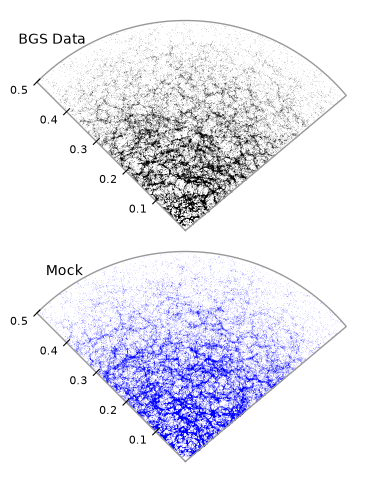

In [47]:
cone_plots(dat,mock,reg)

126394  points in the cone plot


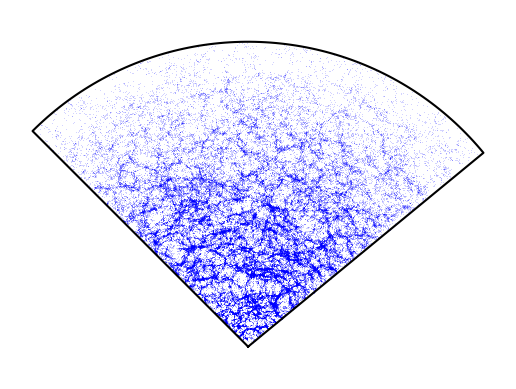

1326783  points in the cone plot


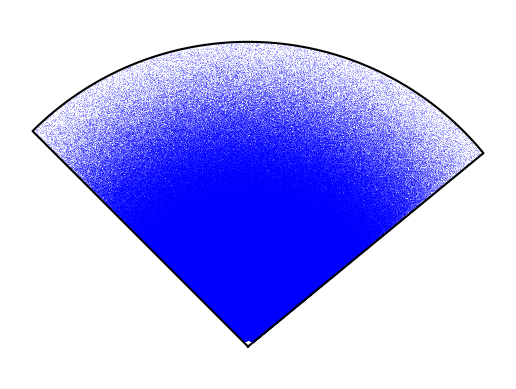

170994  points in the cone plot


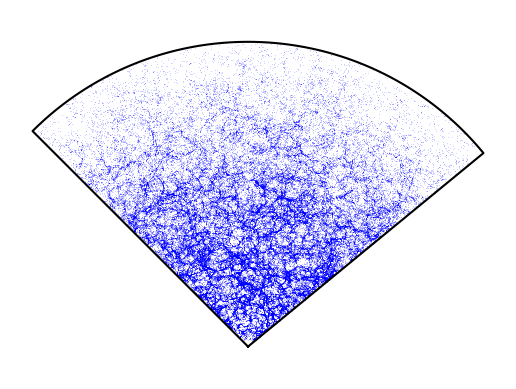

In [48]:
ca.cone_plot(dat,reg)
ca.cone_plot(ran,reg)
ca.cone_plot(mock,reg)

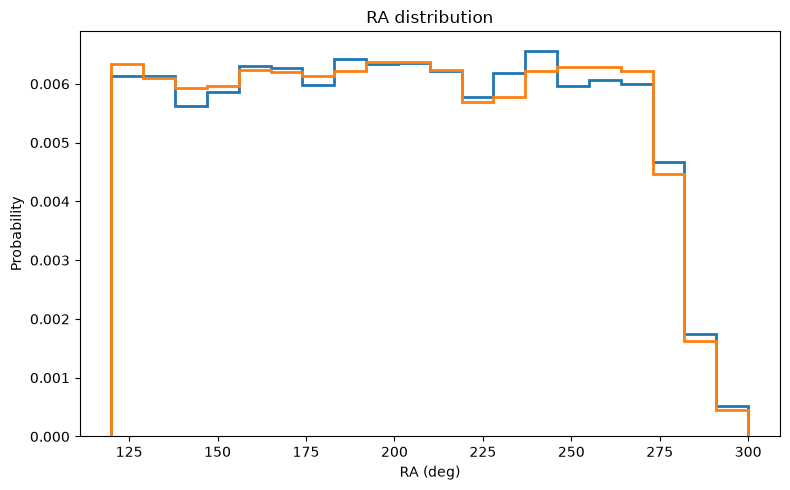

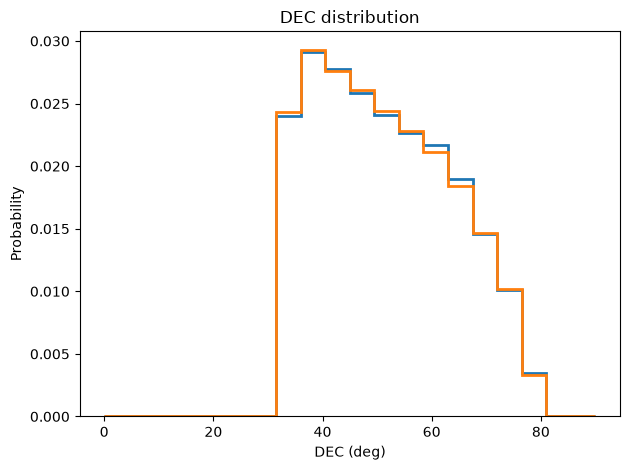

In [49]:


plt.figure(figsize=(8,5))

mask=mock['ABSMAG_R']<-22

bins=np.linspace(120,300,21)
plt.hist(
    mock['RA'][mask],
    bins=bins,
    histtype='step',
    linewidth=2,label='mock',density=True
)
plt.hist(
    ran['RA'],
    bins=bins,
    histtype='step',
    linewidth=2,label='randoms',density=True
)

plt.xlabel('RA (deg)')
plt.ylabel('Probability')
plt.title('RA distribution')

plt.tight_layout()
plt.show()

bins=np.linspace(0,90,21)
plt.hist(
    mock['DEC'],
    bins=bins,
    histtype='step',
    linewidth=2,label='mock',density=True
)
plt.hist(
    ran['DEC'],
    bins=bins,
    histtype='step',
    linewidth=2,label='randoms',density=True
)

plt.xlabel('DEC (deg)')
plt.ylabel('Probability')
plt.title('DEC distribution')

plt.tight_layout()
plt.show()


In [50]:
# Read the mock for the other alternative region as well if available and plot both on the sky
if (reg=='S'):
    mockS=mock
    alt_reg='N'
    mockcat=rf'./sdata/Mocks/mock_{alt_reg}_seed{obs_seed:3d}_sig_lgv{sig_lgv:.2f}.fits'
    # Read the N mock catalogue
    mockN=Table.read(mockcat)
    mockN.info('stats')
elif (reg=='N'):
    mockN=mock
    alt_reg='S'
    mockcat=rf'./sdata/Mocks/mock_{alt_reg}_seed{obs_seed:3d}_sig_lgv{sig_lgv:.2f}.fits'
    # Read the N mock catalogue
    mockS=Table.read(mockcat)
    mockS.info('stats')  

FileNotFoundError: [Errno 2] No such file or directory: './sdata/Mocks/mock_S_seed  0_sig_lgv0.20.fits'

In [ ]:
# All-sky maps 
#  see https://notebook.community/desihub/desiutil/doc/nb/SkyMapExamples for examples of how to make plots like these
def sky_plot(datN,datS):
    """All-sky scatter plot with galactic plane and ecliptic marked"""
    # All-sky scatter plot with galactic plane and ecliptic marked
    ax= ca.init_sky()
    p = ax.scatter(ax.projection_ra(datN['RA']),ax.projection_dec(datN['DEC']),color='blue',s=0.25, marker='.', linewidths=0)
    p = ax.scatter(ax.projection_ra(datS['RA']),ax.projection_dec(datS['DEC']),color='red',s=0.25, marker='.', linewidths=0)


    from matplotlib.lines import Line2D

    handles = [
        Line2D([0], [0],
           marker='o',
           color='white',
           markerfacecolor='blue',
           markersize=6,
           label='North'),
        Line2D([0], [0],
           marker='o',
           color='white',
           markerfacecolor='red',
           markersize=6,
           label='South')
    ]

    ax.legend(
        handles=handles,
        loc='upper right',
        frameon=False
    )
    
    plt.savefig(
    "skymap.jpg",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

    return




In [ ]:
sky_plot(mockN,mockS)